In [20]:
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
import scipy
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

import os

import numpy as np
from scipy.stats import spearmanr
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from mne.stats import spatio_temporal_cluster_test, f_mway_rm, f_threshold_mway_rm, permutation_cluster_1samp_test

In [21]:
def add_subplot_label(ax, label, x=-.21, y=1.225):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')

In [22]:
plt.rcParams.update({
        'font.size': 16,
        'axes.spines.right': False,
        'axes.spines.top': False,
        'xtick.major.size': 6,
        'xtick.major.width': 1.2,
        'ytick.major.size': 6,
        'ytick.major.width': 1.2,
        'legend.frameon': False,
        'legend.handletextpad': 0.1,
        'svg.fonttype': 'none',
        'text.usetex': False
    })

In [23]:
output_dir = '/home/qmoreau/schmidt_data/output'

bursts_all_results_laplac = np.load(f'{output_dir}/bursts_all_results_laplac.npy', allow_pickle=True)

all_bursts = {k: [] for k in ['trial','waveform','peak_freq','peak_amp_iter','peak_amp_base',
                               'peak_time','peak_adjustment','fwhm_freq','fwhm_time','polarity',
                               'waveform_times','condition','electrode','subject','experiment','epochs']}
for bursts in bursts_all_results_laplac:
    for key in bursts:
        if key != 'waveform_times':
            all_bursts[key].extend(bursts[key])
        else:
            all_bursts[key] = bursts[key]
for key in all_bursts:
    all_bursts[key] = np.array(all_bursts[key])

print(np.unique(all_bursts['condition']))

['FS' 'FS_bl' 'GO' 'GO_bl' 'SS' 'SS_bl']


In [24]:
all_bursts={
    'trial': [],
    'waveform': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
    'waveform_times': [],
    'condition': [],
    'electrode': [],
    'subject': [],
    'experiment': [],
    'epochs': []
}
for bursts in bursts_all_results_laplac:
    for key in bursts:
        if not key=='waveform_times':
            all_bursts[key].extend(bursts[key])
        else:
            all_bursts[key]=bursts[key]
            
for key in all_bursts:
    all_bursts[key]=np.array(all_bursts[key])

In [25]:
c3_idx=(all_bursts['electrode']=='C3')
f4_idx=(all_bursts['electrode']=='F4')

In [26]:
# Initialize an empty list to store the mean waveforms
mean_waveforms_laplac_C3 = []

# Loop through unique subjects in the dictionary
unique_subjects = np.unique(all_bursts['subject'])
for subject in unique_subjects:
    # Extract waveforms corresponding to the current subject
    subject_waveforms = all_bursts['waveform'][c3_idx & (all_bursts['subject'] == subject),]*1e3
    
    # Calculate the mean waveform for the subject
    mean_waveform = np.mean(subject_waveforms, axis=0)
    
    # Append the mean waveform to the list
    mean_waveforms_laplac_C3.append(mean_waveform)

# Convert the list to a NumPy array
matrix_mean_waveforms_laplac_C3 = np.array(mean_waveforms_laplac_C3)


# Initialize an empty list to store the mean waveforms
mean_waveforms_laplac_F4 = []

# Loop through unique subjects in the dictionary
unique_subjects = np.unique(all_bursts['subject'])
for subject in unique_subjects:
    # Extract waveforms corresponding to the current subject
    subject_waveforms = all_bursts['waveform'][f4_idx & (all_bursts['subject'] == subject),]*1e3
    
    # Calculate the mean waveform for the subject
    mean_waveform = np.mean(subject_waveforms, axis=0)
    
    # Append the mean waveform to the list
    mean_waveforms_laplac_F4.append(mean_waveform)

# Convert the list to a NumPy array
matrix_mean_waveforms_laplac_F4 = np.array(mean_waveforms_laplac_F4)

In [27]:
waveforms_laplac_C3=all_bursts['waveform'][c3_idx,:]

# Scaling and PCA on the entire dataset
model_laplac_C3 = PCA(n_components=20)
scaler_laplac_C3 = RobustScaler().fit(waveforms_laplac_C3)
waveforms_laplac_C3_std = scaler_laplac_C3.transform(waveforms_laplac_C3)
model_laplac_C3.fit(waveforms_laplac_C3_std)

PCA(n_components=20)

In [28]:
waveforms_laplac_F4=all_bursts['waveform'][f4_idx,:]

# Scaling and PCA on the entire dataset
model_laplac_F4 = PCA(n_components=20)
scaler_laplac_F4 = RobustScaler().fit(waveforms_laplac_F4)
waveforms_laplac_F4_std = scaler_laplac_F4.transform(waveforms_laplac_F4)
model_laplac_F4.fit(waveforms_laplac_F4_std)

PCA(n_components=20)

stat_fun(H1): min=0.106617 max=6.127611
Running initial clustering …
Found 3 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

Overall cluster p-values: [0.0888 0.2159 0.3564]
Pairwise SS vs FS cluster p-values: [0.3828125  0.10791016 0.15966797]
Pairwise FS vs GO cluster p-values: [0.56933594 0.83154297 0.34423828 0.52685547]
Pairwise SS vs GO cluster p-values: [0.06787109 0.39257812 0.65234375]
stat_fun(H1): min=0.008771 max=6.580214
Running initial clustering …
Found 2 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

Overall cluster p-values: [0.0387 0.1029]
3 way cluster
Pairwise SS vs FS cluster p-values: [0.04248047 0.09277344]
Pairwise FS vs GO cluster p-values: [0.24316406 0.29638672 0.75537109 0.19384766]
Pairwise SS vs GO cluster p-values: [0.62255859]


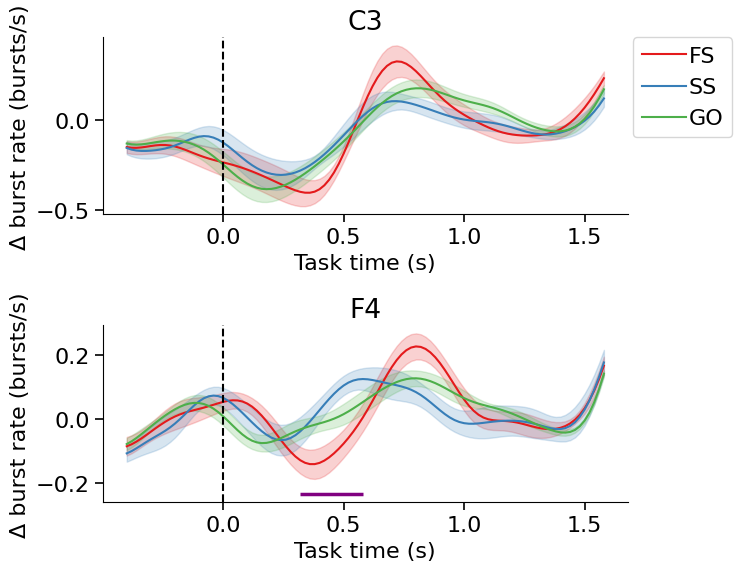

In [29]:
from mne.stats import permutation_cluster_1samp_test
from scipy.stats import t as t_dist

def stat_fun(*args):
    return f_mway_rm(
        np.swapaxes(args, 0, 0),
        factor_levels=[3],
        effects='A',
        return_pvals=False,
    )[0]


def plot_overall_burst_rate(ax, b_idx):
    time_bin_size = 0.02
    time_bins = np.arange(-1, 2 + time_bin_size, time_bin_size)
    rates_smoothed = {'FS': [], 'SS': [], 'GO': []}
    bl_map = {'FS': 'FS_bl', 'SS': 'SS_bl', 'GO': 'GO_bl'}

    for subject in np.unique(all_bursts['subject']):
        subj_idx = b_idx & (all_bursts['subject'] == subject)

        subject_rates = {}
        skip = False
        for cond in ['FS', 'SS', 'GO']:
            cond_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['condition'] == cond)])
            if len(cond_trials) == 0:
                print(f"No trials for {subject} {cond}, skipping subject")
                skip = True
                break

            unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & (all_bursts['condition'] == cond)],
                bins=time_bins
            )
            smoothed_rate = gaussian_filter((unsmoothed_rate / time_bin_size) / len(cond_trials), sigma=5)

            bl_cond = bl_map[cond]
            bl_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['condition'] == bl_cond)])
            if len(bl_trials) > 0:
                bl_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & (all_bursts['condition'] == bl_cond)],
                    bins=time_bins
                )
                bl_rate = gaussian_filter((bl_rate / time_bin_size) / len(bl_trials), sigma=5)
                bl_base_idx = np.where((time_bins[:-1] >= -1) & (time_bins[:-1] < 0))[0]
                base_rate = np.mean(bl_rate[bl_base_idx])
            else:
                print(f"Missing bl for {subject} {cond}, falling back to pre-stimulus baseline")
                base_idx = np.where((time_bins[:-1] >= -1) & (time_bins[:-1] < 0))[0]
                base_rate = np.mean(smoothed_rate[base_idx])

            base_rate = np.maximum(base_rate, 1e-6)
            subject_rates[cond] = (smoothed_rate - base_rate)

        if skip:
            continue

        for cond in ['FS', 'SS', 'GO']:
            rates_smoothed[cond].append(subject_rates[cond])

    time_bins = time_bins[:-1]
    idx = np.where((time_bins >= -0.4) & (time_bins <= 1.6))[0]
    time_bins = time_bins[idx]
    for cond in ['FS', 'SS', 'GO']:
        rates_smoothed[cond] = np.vstack(rates_smoothed[cond])[:, idx]

    cond_colors = {
        'GO': np.array([77, 175, 74]) / 255,
        'FS': np.array([228, 26, 28]) / 255,
        'SS': np.array([55, 126, 184]) / 255,
    }

    for cond in ['FS', 'SS', 'GO']:
        mean_rate = np.mean(rates_smoothed[cond], axis=0)
        sem_rate = np.std(rates_smoothed[cond], axis=0) / np.sqrt(rates_smoothed[cond].shape[0])
        ax.plot(time_bins, mean_rate, label=cond, color=cond_colors[cond])
        ax.fill_between(time_bins, mean_rate - sem_rate, mean_rate + sem_rate, alpha=0.2, color=cond_colors[cond])

    # --- Overall 3-way cluster test ---
    X = np.stack([rates_smoothed['FS'], rates_smoothed['SS'], rates_smoothed['GO']], axis=1)
    threshold = f_threshold_mway_rm(n_subjects=X.shape[0], factor_levels=[3], effects='A')
    _, clusters, cluster_p_values, _ = spatio_temporal_cluster_test(
        X, threshold=threshold, stat_fun=stat_fun,
        n_permutations=10000, tail=1.0, n_jobs=1
    )
    print("Overall cluster p-values:", cluster_p_values)
    for (c_inds,), p_val in zip(clusters, cluster_p_values):
         if p_val < 0.05:
                print('3 way cluster')
#             y_top = ax.get_ylim()[1] * 0.97
#             ax.scatter(time_bins[c_inds], np.full(len(c_inds), y_top),
#                        color='red', s=5, zorder=5)

    # --- Pairwise comparisons ---
    n_subjects = rates_smoothed['FS'].shape[0]
    t_threshold = t_dist.ppf(1 - 0.05, df=n_subjects - 1)

    pairs = [
        ('SS', 'FS', 'purple'),
        ('FS', 'GO', 'brown'),
        ('SS', 'GO', 'darkgreen'),
    ]
    y_offsets = [-0.05, -0.01, -0.08]

    for (c1, c2, color), y_frac in zip(pairs, y_offsets):
        diff = rates_smoothed[c1] - rates_smoothed[c2]
        _, clusters_pw, cluster_p_values_pw, _ = permutation_cluster_1samp_test(
            diff, threshold=t_threshold,
            n_permutations=10000, tail=0, n_jobs=1, verbose=False
        )
        print(f"Pairwise {c1} vs {c2} cluster p-values:", cluster_p_values_pw)
        y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
        y_dot = ax.get_ylim()[0] + y_frac * y_range
        for c_inds, p_val in zip(clusters_pw, cluster_p_values_pw):
             if p_val < 0.05:
                ax.hlines(
                    y_dot, time_bins[c_inds[0][0]], time_bins[c_inds[0][-1]],
                    colors=color, linewidth=2.5, zorder=5, label=f'{c1} vs {c2}'
                )
    ax.axvline(0, color='k', linestyle='--')
    ax.set_xlabel("Task time (s)")
    ax.set_ylabel("Δ burst rate (bursts/s)")


fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(2, 1, figure=fig)

ax = fig.add_subplot(gs[0, 0])
plot_overall_burst_rate(ax, c3_idx)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, frameon=True)
ax.set_title('C3')

ax = fig.add_subplot(gs[1, 0])
plot_overall_burst_rate(ax, f4_idx)
ax.set_title('F4')

plt.tight_layout()
plt.subplots_adjust(right=0.82)

In [30]:
# fig = plt.figure(figsize=(11, 6))
# gs = gridspec.GridSpec(2, 3, figure=fig)

# # Duration distribution
# ax = fig.add_subplot(gs[0, 0])
# _=ax.hist(all_bursts['fwhm_time'][c3_idx]*1e3, bins=700, alpha=0.5, color="blue", label="C3", density=True)
# _=ax.hist(all_bursts['fwhm_time'][f4_idx]*1e3, bins=730, alpha=0.5, color="orange", label="F4", density=True)
# ax.set_xlabel("Duration (ms)")
# ax.set_xlim(np.percentile(all_bursts['fwhm_time']*1e3,[0,99]))
# ax.set_ylabel("Density")
# ax.set_yticks([])
# ax.legend()

# # Amplitude distribution (top left of second row)
# ax = fig.add_subplot(gs[0, 1])
# ax.hist(all_bursts['peak_amp_base'][c3_idx]*1e3, bins=1000, alpha=0.5, color="blue", label="C3", density=True)
# ax.hist(all_bursts['peak_amp_base'][f4_idx]*1e3, bins=1000, alpha=0.5, color="orange", label="F4", density=True)
# ax.set_xlabel("Amplitude (µV)")
# ax.set_xlim(np.percentile(all_bursts['peak_amp_base']*1e3,[0,99]))
# ax.set_ylabel("Density")
# ax.set_yticks([])

# # Peak frequency distribution (bottom left)
# ax = fig.add_subplot(gs[1, 0])
# ax.hist(all_bursts['peak_freq'][c3_idx], bins=18, alpha=0.5, color="blue", label="C3",density=True)
# ax.hist(all_bursts['peak_freq'][f4_idx], bins=18, alpha=0.5, color="orange", label="F4",density=True)
# ax.set_xlabel("Peak Frequency (Hz)")
# ax.set_xlim(np.percentile(all_bursts['peak_freq'],[0,100]))
# ax.set_ylabel("Density")
# ax.set_yticks([])

# # Frequency span distribution (bottom right)
# ax = fig.add_subplot(gs[1, 1])
# ax.hist(all_bursts['fwhm_freq'][c3_idx], bins=10, alpha=0.5, color="blue", label="C3",density=True)
# ax.hist(all_bursts['fwhm_freq'][f4_idx], bins=10, alpha=0.5, color="orange", label="F4",density=True)
# ax.set_xlim([1,7])
# ax.set_xlabel("Frequency Span (Hz)")
# ax.set_ylabel("Density")
# ax.set_yticks([])

# data = matrix_mean_waveforms_laplac_C3 - matrix_mean_waveforms_laplac_F4
# # Perform cluster-based permutation test
# T_obs, clusters, cluster_p_values, H0 = permutation_cluster_1samp_test(
#     data, n_permutations=1000
# )
# ax = fig.add_subplot(gs[0,2])

# # Plot mean waveforms
# ax.plot(
#     all_bursts['waveform_times']*1e3,
#     np.mean(matrix_mean_waveforms_laplac_C3, axis=0),
#     label="C3",
#     color="blue",
# )
# ax.plot(
#     all_bursts['waveform_times']*1e3,
#     np.mean(matrix_mean_waveforms_laplac_F4, axis=0),
#     label="F4",
#     color="orange",
# )

# # Add shaded area using SEM around the mean waveform
# ax.fill_between(
#     all_bursts['waveform_times']*1e3,
#     np.mean(matrix_mean_waveforms_laplac_C3, axis=0) - np.std(matrix_mean_waveforms_laplac_C3, axis=0),
#     np.mean(matrix_mean_waveforms_laplac_C3, axis=0) + np.std(matrix_mean_waveforms_laplac_C3, axis=0),
#     color="blue",
#     alpha=0.1,
# )
# ax.fill_between(
#     all_bursts['waveform_times']*1e3,
#     np.mean(matrix_mean_waveforms_laplac_F4, axis=0) - np.std(matrix_mean_waveforms_laplac_F4, axis=0),
#     np.mean(matrix_mean_waveforms_laplac_F4, axis=0) + np.std(matrix_mean_waveforms_laplac_F4, axis=0),
#     color="orange",
#     alpha=0.1,
# )

# # Plot significant clusters as dots
# for i_c, c in enumerate(clusters):
#     c = c[0]
#     if cluster_p_values[i_c] < 0.05:
#         # Add dots at the time points of the cluster
#         cluster_times = all_bursts['waveform_times'][c]*1e3
#         cluster_midpoint = 2  # Midpoint between the offsets for clarity
#         ax.scatter(cluster_times, [cluster_midpoint] * len(cluster_times), color='red', s=10)
# ax.set_xlabel("Time (ms)")
# ax.set_ylabel('Amplitude (µV)')
# ax.legend(loc='lower right')

# # Parameters
# pcs_to_analyze_c = 20
# min_pcs = min(model_laplac_C3.components_.shape[0], model_laplac_F4.components_.shape[0])

# # Calculate the component correlation matrix
# comp_corrmat_C3_F4 = np.zeros((min_pcs, min_pcs))
# for i in range(min_pcs):
#     for j in range(min_pcs):
#         comp_corrmat_C3_F4[i, j] = np.abs(spearmanr(model_laplac_C3.components_[i, :], model_laplac_F4.components_[j, :])[0])

# # Plot the correlation matrix
# ax = fig.add_subplot(gs[1,2])
# im=ax.imshow(comp_corrmat_C3_F4, aspect='auto', origin='upper', cmap='viridis', vmin=0, vmax=1)
# plt.colorbar(im,label='|r|')
# ax.set_xlabel('F4 PC')
# ax.set_ylabel('C3 PC')

# plt.tight_layout()
# plt.savefig('/home/qmoreau/stop_go_bursts/figures/figure_01_burst_features.pdf')


stat_fun(H1): min=0.106617 max=6.127611
Running initial clustering …
Found 3 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

Overall cluster p-values: [0.0909 0.2104 0.3499]
Pairwise SS vs FS cluster p-values: [0.3828125  0.10791016 0.15966797]
Pairwise FS vs GO cluster p-values: [0.56933594 0.83154297 0.34423828 0.52685547]
Pairwise SS vs GO cluster p-values: [0.06787109 0.39257812 0.65234375]
stat_fun(H1): min=0.008771 max=6.580214
Running initial clustering …
Found 2 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

Overall cluster p-values: [0.0359 0.1044]
3 way cluster
Pairwise SS vs FS cluster p-values: [0.04248047 0.09277344]
Pairwise FS vs GO cluster p-values: [0.24316406 0.29638672 0.75537109 0.19384766]
Pairwise SS vs GO cluster p-values: [0.62255859]


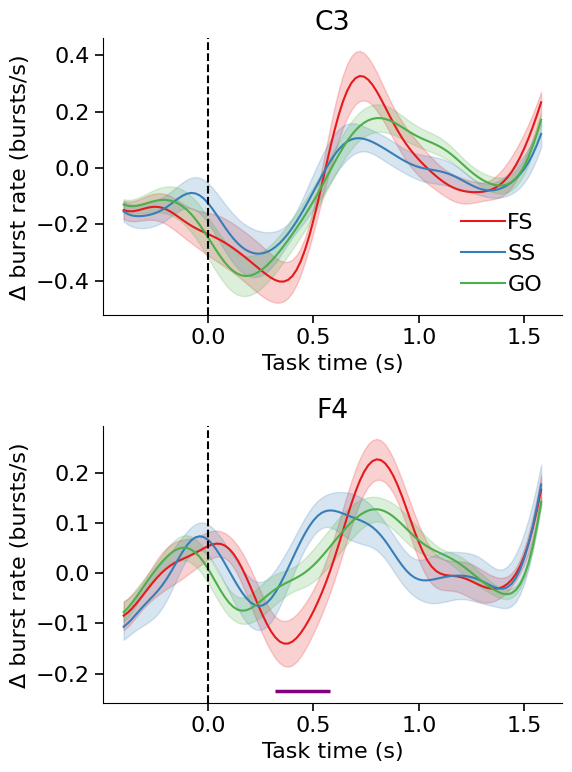

In [31]:
fig = plt.figure(figsize=(6, 8))
gs = gridspec.GridSpec(2, 1, figure=fig)

ax = fig.add_subplot(gs[0, 0])
plot_overall_burst_rate(ax, c3_idx)
ax.legend()
ax.set_title('C3')

ax = fig.add_subplot(gs[1, 0])
plot_overall_burst_rate(ax, f4_idx)
ax.set_title('F4')

plt.tight_layout()
# plt.savefig('./figures/figure_xx_burst_rate.pdf')

In [32]:
# def plot_overall_burst_rate(b_idx):
#     time_bin_size = 0.02
#     time_bins = np.arange(-1, 2 + time_bin_size, time_bin_size)
#     rates_smoothed = {'FS': [], 'SS': [], 'GO': []}
#     subjects=np.unique(all_bursts['subject'])
    
#     # Define colors for each condition
#     colors = {
#         'FS': 'darkred',      # Failed stop
#         'SS': 'darkblue',     # Successful stop
#         'GO': 'darkgreen'     # Go
#     }
    
#     # Calculate smoothed burst rates by quantile x condition x subject
#     for subject in subjects:
#         subj_idx = b_idx & (all_bursts['subject'] == subject)
#         for cond in ['FS', 'SS', 'GO']:
#             cond_trials = np.unique(
#                 all_bursts['trial'][subj_idx & (all_bursts['condition'] == cond)]
#             )
#             unsmoothed_rate, _ = np.histogram(
#                 all_bursts['peak_time'][subj_idx & (all_bursts['condition'] == cond)],
#                 bins=time_bins
#             )
#             # Convert to rate
#             unsmoothed_rate = (unsmoothed_rate / time_bin_size) / len(cond_trials)
#             smoothed_rate = gaussian_filter(unsmoothed_rate, sigma=2)
#             base_idx = np.where((time_bins >= -0.6) & (time_bins < 0))[0]
#             base_rate = np.mean(smoothed_rate[base_idx])
#             smoothed_rate = smoothed_rate - base_rate
#             rates_smoothed[cond].append(smoothed_rate)
    
#     # Truncate last bin
#     time_bins = time_bins[:-1]
#     idx = np.where((time_bins >= -0.6) & (time_bins <= 1.6))[0]
#     time_bins = time_bins[idx]
    
#     # Convert each quantile+condition's list of arrays to np arrays
#     for cond in ['FS', 'SS', 'GO']:
#         rates_smoothed[cond] = np.vstack(rates_smoothed[cond])[:, idx]
    
#     plt.figure(figsize=(12, 6))
#     plt.rcParams.update({
#         'font.size': 16,
#         'axes.spines.right': False,
#         'axes.spines.top': False,
#         'xtick.major.size': 6,
#         'xtick.major.width': 1.2,
#         'ytick.major.size': 6,
#         'ytick.major.width': 1.2,
#         'legend.frameon': False,
#         'legend.handletextpad': 0.1,
#         'svg.fonttype': 'none',
#         'text.usetex': False
#     })
#     ax = plt.subplot(1,1,1)
    
#     # Plot grand averages for each condition
#     for cond in ['FS', 'SS', 'GO']:
#         mean_rate = np.mean(rates_smoothed[cond], axis=0)
#         sem_rate = np.std(rates_smoothed[cond], axis=0) / np.sqrt(rates_smoothed[cond].shape[0])
#         ax.plot(time_bins, mean_rate, label=cond, color=colors[cond], linewidth=2.5)
#         ax.fill_between(time_bins, mean_rate - sem_rate, mean_rate + sem_rate, 
#                         alpha=0.2, color=colors[cond])
    
#     # Add dashed vertical line at time 0
#     ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
#     # X shape: (n_subjects, n_conditions, n_times)
#     X = np.stack((
#         rates_smoothed['FS'],
#         rates_smoothed['SS'],
#         rates_smoothed['GO']
#     ), axis=1)
#     print(X.shape)
    
#     # For a one-way repeated-measures ANOVA with 3 levels, define factor_levels=[3].
#     # We will test effect 'A' (the only factor).
#     factor_levels = [3]
#     effects = 'A'  # Single factor
    
#     # Compute threshold for cluster test
#     threshold = f_threshold_mway_rm(
#         n_subjects=X.shape[0],
#         factor_levels=factor_levels,
#         effects=effects
#     )
    
#     # Run cluster-based permutation on F-stat
#     # FIXED: Changed n_jobs=-1 to n_jobs=1 to avoid pickling error
#     f_obs, clusters, cluster_p_values, H0 = spatio_temporal_cluster_test(
#         X,
#         threshold=threshold,
#         stat_fun=stat_fun,
#         n_permutations=10000,
#         tail=1.0,
#         n_jobs=1  # Changed from -1 to avoid pickling error
#     )
    
#     # Mark significant cluster spans and print details
#     print("\nSignificant clusters:")
#     sig_cluster_count = 0
#     for (c_inds,), p_val in zip(clusters, cluster_p_values):
#         if p_val < 0.05:  # cluster-level alpha
#             sig_cluster_count += 1
#             # c_inds is a slice or range of time indices
#             start_time = time_bins[c_inds[0]]
#             end_time = time_bins[c_inds[-1]]
            
#             print(f"  Cluster {sig_cluster_count}: {start_time:.3f}s to {end_time:.3f}s, p = {p_val:.4f}")
            
#             ax.axvspan(
#                 start_time, 
#                 end_time,
#                 color='grey', alpha=0.2
#             )
    
#     if sig_cluster_count == 0:
#         print("  No significant clusters found")
    
#     # FIXED: Moved posthoc tests OUTSIDE the if block so they run when clusters ARE found
#     posthoc_results = posthoc_pairwise_tests(X, time_bins, clusters, cluster_p_values)
    
#     print("\n=== POSTHOC PAIRWISE TESTS ===")
#     for result in posthoc_results:
#         print(f"\nCluster {result['cluster_idx']}: "
#               f"{result['time_window'][0]:.3f}s to {result['time_window'][1]:.3f}s "
#               f"(cluster p = {result['cluster_p']:.4f})")
#         print("  Pairwise comparisons (Bonferroni-corrected):")
        
#         for test in result['pairwise_tests']:
#             sig_marker = "***" if test['p_corrected'] < 0.001 else \
#                          "**" if test['p_corrected'] < 0.01 else \
#                          "*" if test['p_corrected'] < 0.05 else "ns"
#             print(f"    {test['comparison']}: "
#                   f"t = {test['t_stat']:6.3f}, "
#                   f"p = {test['p_corrected']:.4f} {sig_marker}, "
#                   f"? = {test['mean_diff']:+.4f}")
    
#     ax.set_xlabel("Task time (s)")
#     ax.set_ylabel("Burst rate (baseline-corrected)")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

In [33]:
def posthoc_pairwise_tests(X, time_bins, clusters, cluster_p_values, alpha=0.05):
    """
    Perform pairwise posthoc tests on averaged data within significant clusters.
    """
    conditions = ['FS', 'SS', 'GO']
    pairwise_comparisons = [
        ('FS', 'SS'),
        ('FS', 'GO'),
        ('SS', 'GO')
    ]
    
    results = []
    
    for cluster_idx, ((c_inds,), p_val) in enumerate(zip(clusters, cluster_p_values)):
        if p_val < alpha:
            # Average data over the significant cluster
            cluster_data = X[:, :, c_inds].mean(axis=2)
            
            start_time = time_bins[c_inds[0]]
            end_time = time_bins[c_inds[-1]]
            
            cluster_result = {
                'cluster_idx': cluster_idx + 1,
                'time_window': (start_time, end_time),
                'cluster_p': p_val,
                'pairwise_tests': []
            }
            
            p_values = []
            for cond1, cond2 in pairwise_comparisons:
                idx1 = conditions.index(cond1)
                idx2 = conditions.index(cond2)
                
                t_stat, p_value = ttest_rel(cluster_data[:, idx1], cluster_data[:, idx2])
                mean_diff = cluster_data[:, idx1].mean() - cluster_data[:, idx2].mean()
                
                p_values.append(p_value)
                cluster_result['pairwise_tests'].append({
                    'comparison': f'{cond1} vs {cond2}',
                    't_stat': t_stat,
                    'p_value': p_value,
                    'mean_diff': mean_diff
                })
            
            # Apply Bonferroni correction (import now at top)
            _, p_corrected, _, _ = multipletests(p_values, method='bonferroni')
            
            for i, test_result in enumerate(cluster_result['pairwise_tests']):
                test_result['p_corrected'] = p_corrected[i]
            
            results.append(cluster_result)
    
    return results

In [34]:
# plot_overall_burst_rate(c3_idx)

In [35]:
# plot_overall_burst_rate(f4_idx)

stat_fun(H1): min=0.305511 max=18.808371
Running initial clustering …
Found 1 cluster


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

Overall cluster p-values: [0.0001]
3 way cluster
Pairwise SS vs FS cluster p-values: [0.00048828]
Pairwise FS vs GO cluster p-values: []


/tmp/ipykernel_5649/1100015872.py:107: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  _, clusters_pw, cluster_p_values_pw, _ = permutation_cluster_1samp_test(


Pairwise SS vs GO cluster p-values: [0.44433594 0.00048828]
stat_fun(H1): min=0.117732 max=15.427240
Running initial clustering …
Found 3 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

Overall cluster p-values: [0.3239 0.1596 0.0009]
3 way cluster
Pairwise SS vs FS cluster p-values: [0.15917969 0.58105469 0.00585938]
Pairwise FS vs GO cluster p-values: []


/tmp/ipykernel_5649/1100015872.py:107: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  _, clusters_pw, cluster_p_values_pw, _ = permutation_cluster_1samp_test(


Pairwise SS vs GO cluster p-values: [0.18603516 0.35107422 0.00048828]


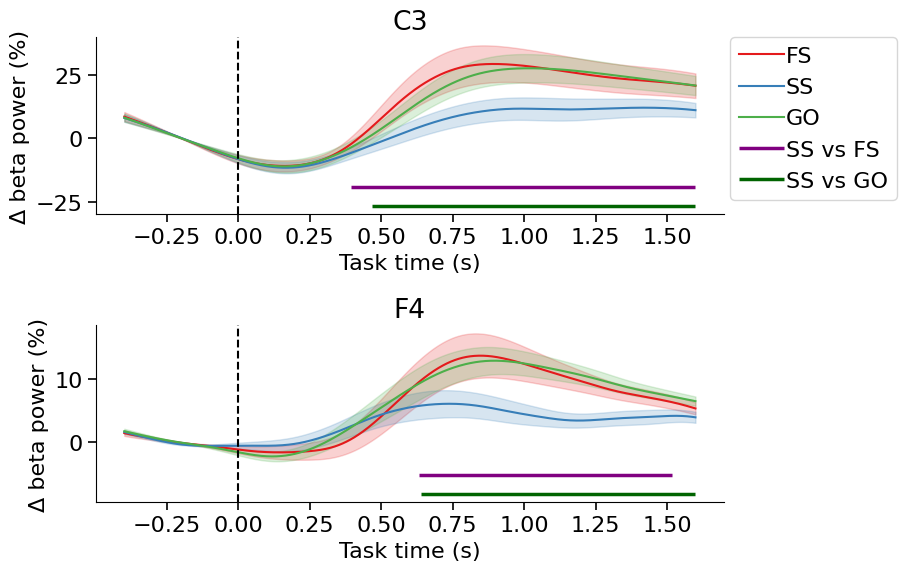

In [36]:
def plot_overall_beta_power(ax, electrode, path='/home/qmoreau/schmidt_data/', baseline='pre_stop'):
    """
    baseline : 'pre_stop'  uses -0.4 to 0s of the task epoch (stop-locked)
               'pre_cue'  uses the _bl cue-locked epoch (-1 to 1s)
    """
    subject_ids = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d)) and d.startswith('S')])

    cond_colors = {
        'GO': np.array([77, 175, 74]) / 255,
        'FS': np.array([228, 26, 28]) / 255,
        'SS': np.array([55, 126, 184]) / 255,
    }

    rates_smoothed = {'FS': [], 'SS': [], 'GO': []}
    time = None
    for subject_id in subject_ids:
        subject_out_dir = os.path.join(path, subject_id)
        subject_data = {}
        missing = False
        for cond in ['FS', 'SS', 'GO']:
            fpath = os.path.join(subject_out_dir, f'{subject_id}_{cond}_{electrode}_beta_power.npz')
            if not os.path.exists(fpath):
                print(f"Missing: {fpath}")
                missing = True
                break
            d = np.load(fpath)
            if time is None:
                time = d['time']
            subject_data[cond] = d['beta_pow']  # (n_trials, n_times)
        if missing:
            continue
        dt = np.mean(np.diff(time))
        sigma_samples = 0.04 / dt  # 40ms smoothing
        for cond in ['FS', 'SS', 'GO']:
            mean_pow = gaussian_filter(np.mean(subject_data[cond], axis=0), sigma=sigma_samples)

            if baseline == 'pre_cue':
                bl_fpath = os.path.join(subject_out_dir, f'{subject_id}_{cond}_bl_{electrode}_beta_power.npz')
                if os.path.exists(bl_fpath):
                    bl_d = np.load(bl_fpath)
                    bl_pow = bl_d['beta_pow']
                    bl_time = bl_d['time'] if 'time' in bl_d else time
                    bl_mean = gaussian_filter(np.mean(bl_pow, axis=0), sigma=sigma_samples)
                    bl_base_idx = np.where((bl_time >= -1) & (bl_time < 0))[0]
                    base_mean = np.mean(bl_mean[bl_base_idx])
                else:
                    print(f"Missing bl for {subject_id} {cond}, falling back to pre-stimulus baseline")
                    base_idx = np.where((time >= -0.4) & (time < 0))[0]
                    base_mean = np.mean(mean_pow[base_idx])
            elif baseline == 'pre_stop':
                base_idx = np.where((time >= -0.4) & (time < 0))[0]
                base_mean = np.mean(mean_pow[base_idx])
            else:
                raise ValueError(f"baseline must be 'pre_stop' or 'pre_cue', got '{baseline}'")

            rates_smoothed[cond].append((mean_pow - base_mean) / base_mean * 100)

    if time is None or len(rates_smoothed['GO']) == 0:
        print(f"No data found for {electrode}")
        return

    # Trim to -0.4 to 1.6s
    idx = np.where((time >= -0.4) & (time <= 1.6))[0]
    time = time[idx]
    for cond in ['FS', 'SS', 'GO']:
        rates_smoothed[cond] = np.vstack(rates_smoothed[cond])[:, idx]

    # Plot
    for cond in ['FS', 'SS', 'GO']:
        mean_r = np.mean(rates_smoothed[cond], axis=0)
        sem_r = np.std(rates_smoothed[cond], axis=0) / np.sqrt(rates_smoothed[cond].shape[0])
        ax.plot(time, mean_r, label=cond, color=cond_colors[cond])
        ax.fill_between(time, mean_r - sem_r, mean_r + sem_r, alpha=0.2, color=cond_colors[cond])

    ax.axvline(0, color='k', linestyle='--')
    ax.set_xlabel("Task time (s)")
    ax.set_ylabel("Δ beta power (%)")

    # --- Overall 3-way cluster test ---
    X = np.stack([rates_smoothed['FS'], rates_smoothed['SS'], rates_smoothed['GO']], axis=1)
    threshold = f_threshold_mway_rm(n_subjects=X.shape[0], factor_levels=[3], effects='A')
    _, clusters, cluster_p_values, _ = spatio_temporal_cluster_test(
        X, threshold=threshold, stat_fun=stat_fun,
        n_permutations=10000, tail=1.0, n_jobs=1
    )
    print("Overall cluster p-values:", cluster_p_values)
    for (c_inds,), p_val in zip(clusters, cluster_p_values):
        if p_val < 0.05:
            print("3 way cluster")
#             y_top = ax.get_ylim()[1] * 0.97
#             ax.hlines(y_top, time[c_inds[0]], time[c_inds[-1]],
#                       colors='red', linewidth=2.5, zorder=5)

    # --- Pairwise comparisons ---
    n_subjects = rates_smoothed['FS'].shape[0]
    t_threshold = t_dist.ppf(1 - 0.05, df=n_subjects - 1)

    pairs = [
        ('SS', 'FS', 'purple'),
        ('FS', 'GO', 'brown'),
        ('SS', 'GO', 'darkgreen'),
    ]
    y_offsets = [-0.05, -0.01, -0.08]

    for (c1, c2, color), y_frac in zip(pairs, y_offsets):
        diff = rates_smoothed[c1] - rates_smoothed[c2]
        _, clusters_pw, cluster_p_values_pw, _ = permutation_cluster_1samp_test(
            diff, threshold=t_threshold,
            n_permutations=10000, tail=0, n_jobs=1, verbose=False
        )
        print(f"Pairwise {c1} vs {c2} cluster p-values:", cluster_p_values_pw)
        y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
        y_dot = ax.get_ylim()[0] + y_frac * y_range
        for c_inds, p_val in zip(clusters_pw, cluster_p_values_pw):
            if p_val < 0.05:
                ax.hlines(
                    y_dot, time[c_inds[0][0]], time[c_inds[0][-1]],
                    colors=color, linewidth=2.5, zorder=5, label=f'{c1} vs {c2}'
                )


# Plot
fig = plt.figure(figsize=(9, 6))
gs = gridspec.GridSpec(2, 1, figure=fig)

ax = fig.add_subplot(gs[0, 0])
plot_overall_beta_power(ax, 'C3', baseline='pre_stop')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, frameon=True)
ax.set_title('C3')

ax = fig.add_subplot(gs[1, 0])
plot_overall_beta_power(ax, 'F4', baseline='pre_stop')
ax.set_title('F4')

plt.tight_layout()
plt.subplots_adjust(right=0.82)


stat_fun(H1): min=0.117732 max=15.427240
Running initial clustering …
Found 3 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

Overall cluster p-values: [0.3159 0.1587 0.0005]
3 way cluster
Pairwise SS vs FS cluster p-values: [0.15917969 0.58105469 0.00585938]
Pairwise FS vs GO cluster p-values: []


/tmp/ipykernel_5649/1100015872.py:107: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  _, clusters_pw, cluster_p_values_pw, _ = permutation_cluster_1samp_test(


Pairwise SS vs GO cluster p-values: [0.18603516 0.35107422 0.00048828]
stat_fun(H1): min=0.008771 max=6.580214
Running initial clustering …
Found 2 clusters


...

Overall cluster p-values: [0.0002]
3 way cluster
Pairwise SS vs FS cluster p-values: [0.00048828]
Pairwise FS vs GO cluster p-values: []


/tmp/ipykernel_5649/1100015872.py:107: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  _, clusters_pw, cluster_p_values_pw, _ = permutation_cluster_1samp_test(


Pairwise SS vs GO cluster p-values: [0.44433594 0.00048828]
stat_fun(H1): min=0.106617 max=6.127611
Running initial clustering …
Found 3 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

Overall cluster p-values: [0.0913 0.2141 0.3641]
Pairwise SS vs FS cluster p-values: [0.3828125  0.10791016 0.15966797]
Pairwise FS vs GO cluster p-values: [0.56933594 0.83154297 0.34423828 0.52685547]
Pairwise SS vs GO cluster p-values: [0.06787109 0.39257812 0.65234375]


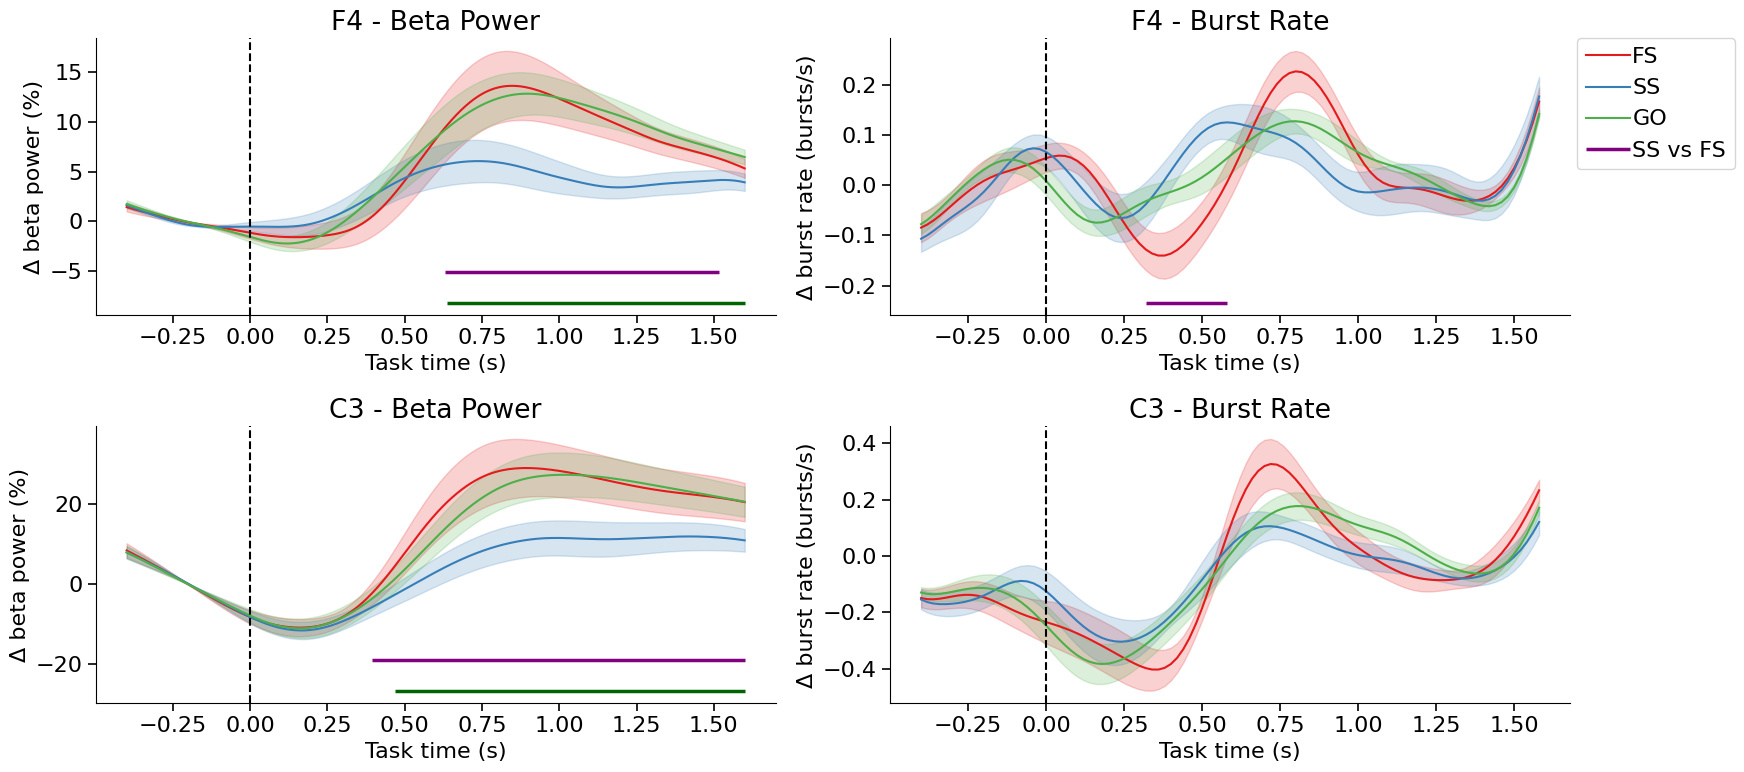

In [37]:
fig = plt.figure(figsize=(18, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)


# Row 0: F
ax = fig.add_subplot(gs[0, 0])
plot_overall_beta_power(ax, 'F4')
ax.set_title('F4 - Beta Power')

ax = fig.add_subplot(gs[0, 1])
plot_overall_burst_rate(ax, f4_idx)
ax.set_title('F4 - Burst Rate')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, frameon=True)


# Row 1: F4
ax = fig.add_subplot(gs[1, 0])
plot_overall_beta_power(ax, 'C3')
ax.set_title('C3 - Beta Power')

ax = fig.add_subplot(gs[1, 1])
plot_overall_burst_rate(ax, c3_idx)
ax.set_title('C3 - Burst Rate')


plt.tight_layout()
plt.subplots_adjust(right=0.88)


Group SSRT: 215.6 ± 6.3 ms
stat_fun(H1): min=0.117732 max=15.427240
Running initial clustering …
Found 3 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

Overall cluster p-values: [0.3166 0.1573 0.0007]
3 way cluster
Pairwise SS vs FS cluster p-values: [0.15917969 0.58105469 0.00585938]
Pairwise FS vs GO cluster p-values: []


/tmp/ipykernel_5649/1100015872.py:107: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  _, clusters_pw, cluster_p_values_pw, _ = permutation_cluster_1samp_test(


Pairwise SS vs GO cluster p-values: [0.18603516 0.35107422 0.00048828]
stat_fun(H1): min=0.008771 max=6.580214
Running initial clustering …
Found 2 clusters


...

Overall cluster p-values: [0.0001]
3 way cluster
Pairwise SS vs FS cluster p-values: [0.00048828]
Pairwise FS vs GO cluster p-values: []


/tmp/ipykernel_5649/1100015872.py:107: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  _, clusters_pw, cluster_p_values_pw, _ = permutation_cluster_1samp_test(


Pairwise SS vs GO cluster p-values: [0.44433594 0.00048828]
stat_fun(H1): min=0.106617 max=6.127611
Running initial clustering …
Found 3 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

Overall cluster p-values: [0.0862 0.2101 0.3587]
Pairwise SS vs FS cluster p-values: [0.3828125  0.10791016 0.15966797]
Pairwise FS vs GO cluster p-values: [0.56933594 0.83154297 0.34423828 0.52685547]
Pairwise SS vs GO cluster p-values: [0.06787109 0.39257812 0.65234375]


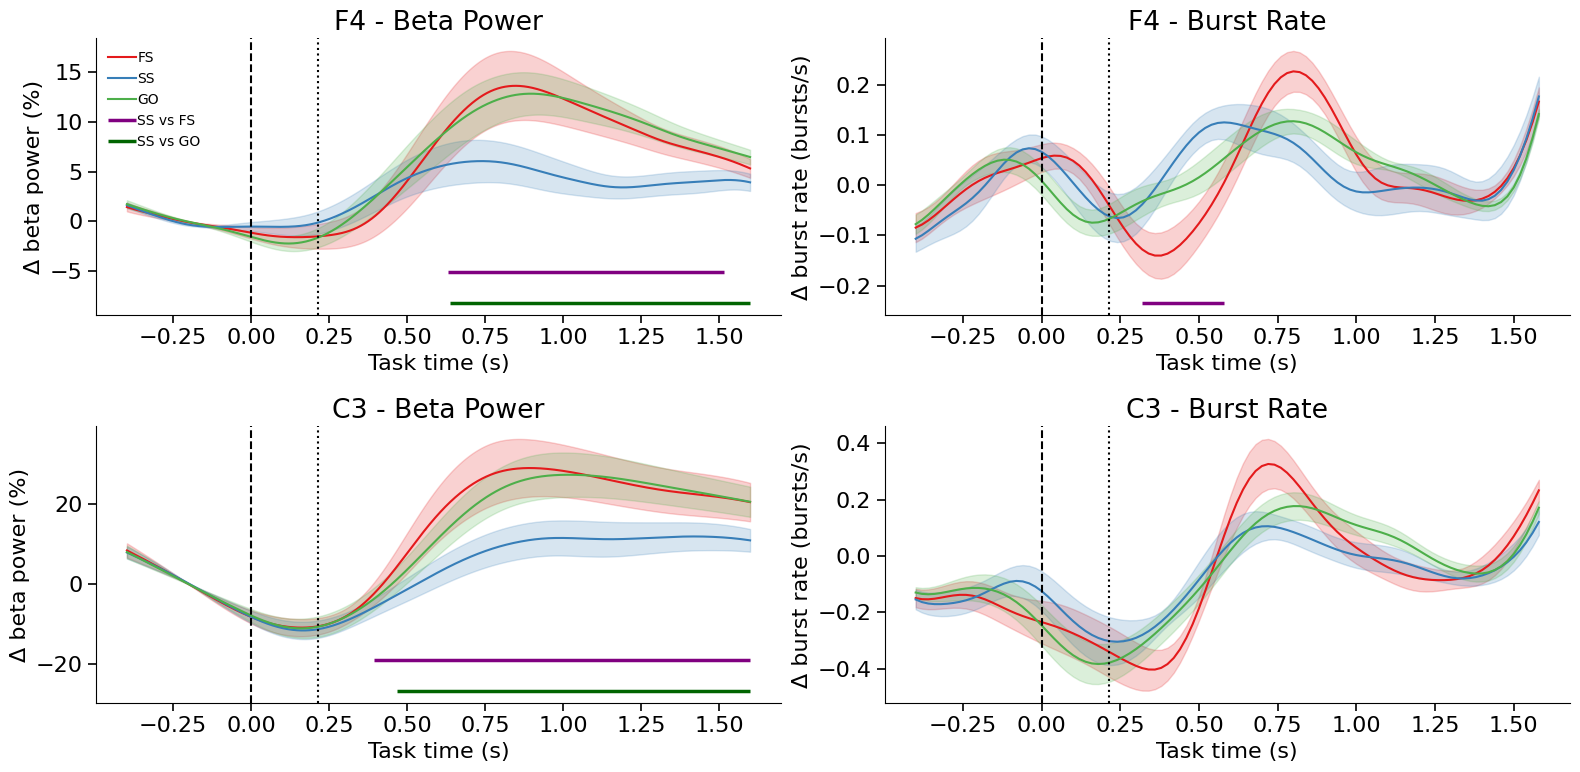

In [38]:
def compute_ssrt(data_dir='/home/common/bonaiuto/stop_go_bursts/data/'):
    """
    Integration method SSRT per subject using behave_full_corrected_v2.mat:
      - go_cor_trls: correct GO trial indices (1-based)
      - stop_cor_trls: SS trial indices
      - stop_err_trls: FS trial indices
      - RT: RT for all trials (ms)
      - ssd: SSD for all stop trials (ms)
      SSRT = nth_GO_RT (at percentile p_respond) - mean_SSD
    Returns mean and SEM across subjects in seconds.
    """
    beh_path = os.path.join(data_dir, 'Dataset_1/Study5_BEH_data/')
    subject_ids = ['S1', 'S2', 'S3', 'S5', 'S6', 'S7', 'S8', 'S10', 'S11', 'S13', 'S14', 'S15']
    ssrts = []

    for subject_id in subject_ids:
        fpath = os.path.join(beh_path, f'{subject_id}_behave_full_corrected_v2.mat')
        if not os.path.exists(fpath):
            print(f"Missing: {fpath}")
            continue

        mat = scipy.io.loadmat(fpath)
        RT = mat['RT'].flatten()               # (n_trials,) in ms
        ssd = mat['ssd'].flatten()             # (n_stop_trials,) in ms
        go_cor  = mat['go_cor_trls'].flatten() - 1   # 0-based
        ss_trls = mat['stop_cor_trls'].flatten() - 1
        fs_trls = mat['stop_err_trls'].flatten() - 1

        go_rts   = RT[go_cor]
        go_rts   = go_rts[~np.isnan(go_rts)]
        mean_ssd = np.nanmean(ssd)

        n_ss = len(ss_trls)
        n_fs = len(fs_trls)
        if (n_ss + n_fs) == 0 or len(go_rts) == 0:
            print(f"Skipping {subject_id}: insufficient data")
            continue

        p_respond = n_fs / (n_ss + n_fs)
        nth_rt    = np.percentile(go_rts, p_respond * 100)
        ssrt      = (nth_rt - mean_ssd) / 1000   # ms s
        ssrts.append(ssrt)
#         print(f"{subject_id}: n_SS={n_ss}, n_FS={n_fs}, p_respond={p_respond:.2f}, "
#               f"nth_RT={nth_rt:.1f}ms, mean_SSD={mean_ssd:.1f}ms, SSRT={ssrt*1000:.1f}ms")

    ssrts = np.array(ssrts)
    return ssrts.mean(), ssrts.std() / np.sqrt(len(ssrts))


#  Compute SSRT 
mean_ssrt, sem_ssrt = compute_ssrt()
print(f"\nGroup SSRT: {mean_ssrt*1000:.1f} ± {sem_ssrt*1000:.1f} ms")


#  Figure
fig = plt.figure(figsize=(18, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

axes = []

ax = fig.add_subplot(gs[0, 0])
plot_overall_beta_power(ax, 'F4')
ax.legend(loc='upper left', fontsize=10)
ax.set_title('F4 - Beta Power')
axes.append(ax)

ax = fig.add_subplot(gs[0, 1])
plot_overall_burst_rate(ax, f4_idx)
ax.set_title('F4 - Burst Rate')
axes.append(ax)

ax = fig.add_subplot(gs[1, 0])
plot_overall_beta_power(ax, 'C3')
ax.set_title('C3 - Beta Power')
axes.append(ax)

ax = fig.add_subplot(gs[1, 1])
plot_overall_burst_rate(ax, c3_idx)
ax.set_title('C3 - Burst Rate')
axes.append(ax)

# Add SSRT line to all panels
for ax in axes:
    ax.axvline(mean_ssrt, color='black', linestyle=':', linewidth=1.5,
               label=f'SSRT ({mean_ssrt*1000:.0f} ms)', zorder=6)

plt.tight_layout()
plt.subplots_adjust(right=0.88)
plt.savefig('/home/qmoreau/schmidt_data/figures/figure_01_beta_and_burst_rate.pdf', bbox_inches='tight')